# CS-421 Machine learning for behavioral data
## Project - GoGymi dataset
### Fatumah binta Doukouré 340969 - Louis Tschanz 315774 - Majandra Garcia 347470

---

**Main research question:** Which observable student behaviors, including written response quality, chatbot interaction patterns, and early platform engagement, are most predictive of academic success?

- **Sub-question 1:** How do the linguistic and semantic characteristics of students' written responses relate to their performance across essay and text comprehension assessments?

- **Sub-question 2:** To what extent does chatbot (GymiTrainer) engagement, in terms of : frequency, interaction intensity, and feedback patterns, influence student performance in quizzes and essays?

- **Sub-question 3:** To what extent can early learning behaviors, such as exercise diversity, session consistency, and content focus, predict which students will struggle or succeed later in their learning progression?

---


## Dataset Description

### Main parts of the dataset

- **User tables**
  - `students.csv`, `teachers.csv`
  - user identifiers, group membership, account creation time

- **Platform activity**
  - `pageviews.csv`
  - `events/*.csv`
  - navigation and fine-grained interaction logs (clicks, scroll, question views, media events, chatbot open/close)

- **Chatbot usage**
  - `gymitrainer.csv`
  - `gymitrainer_feedback.csv`
  - conversation threads with the AI chatbot and user feedback on those interactions

- **Performance / outcome tables**
  - `quiz_results.csv`
  - `math_results.csv`
  - `text_results.csv`
  - `essay_results.csv`
  - `essay_feedback.csv`

- **Supporting / mapping tables**
  - `course_ids.csv`
  - `math_questions.csv`
  - `quiz_questions.csv`
  - `text_questions.csv`
  - `comments.csv`

### Most important identifiers

The main linking variable across the dataset is usually:

- `user_id`

Other useful keys include:

- `result_id` for essay submissions
- `thread_id` for chatbot feedback
- `question_id` for question-level results
- `url` / `post_id` for linking pages to course content

### Practical note

The dataset mixes several time formats:
- Unix timestamps in **seconds**
- client-side event timestamps in **milliseconds**
- datetime strings in `pageviews.csv`

---

#### Useful datasets per sub-question:

**Sub-question 1**
- essay_results : the essay text + all AI dimension scores are your core data
- essay_feedback : teacher grades give you a ground truth label
- text_results : student answer text + points
- text_questions : question metadata to contextualize answers
- course_ids : to distinguish Langzeit vs Kurzzeitgymnasium

**Sub-question 2**
- gymitrainer : conversation content, frequency, thread length
- gymitrainer_feedback : user satisfaction scores
- events_gymitrainer : open/close timestamps give you session duration
- quiz_results : outcome to predict
- essay_results : second outcome
- pageviews : useful to establish when a student visited a page relative to chatbot use

**Sub-question 3**
- events_heartbeat : session consistency, time on platform
- events_questions : exercise diversity
- quiz_results : captures progression over time
- math_results : another longitudinal performance signal
- pageviews : content focus (which topics visited)
- students : group membership to control for classroom effects

---

## Sub-question 1

#### How do the linguistic and semantic characteristics of students' written responses relate to their performance across essay and text comprehension assessments?

In [16]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance

In [43]:
import sys
sys.path.append('..')  # one directory up

import importlib
import helpers
importlib.reload(helpers)

<module 'helpers' from '/Users/louistschanz/Documents/EPFL/MA4/MLBD_2026/Q1/helpers.py'>

## Part 1 — Essay-based analysis
Can simple linguistic surface features extracted from students' essays predict essay performance?

## First prediction task
We start with a focused regression task on `essay_results.csv`.

- **Input:** essay metadata and engineered features extracted from the raw essay text
- **Target:** an essay assessment score, initially `structure__coherence`
- **Goal:** test whether simple observable linguistic characteristics of essays already carry predictive signal about writing quality

## Why this first step?
This first step provides a clean baseline before moving to:
1. richer semantic text features
2. text comprehension responses from `text_results.csv`
3. a broader comparison across assessment types

In [54]:
# Directory
print("Python working directory:", os.getcwd())

data_dir = '../data'
assert os.path.isdir(data_dir), f"File not found: {data_dir}"  # check files exist

fig_dir = './figures_q1'
os.makedirs(fig_dir, exist_ok=True)
print("Figures will be saved in:", os.path.abspath(fig_dir))

Python working directory: /Users/louistschanz/Documents/EPFL/MA4/MLBD_2026/Q1
Figures will be saved in: /Users/louistschanz/Documents/EPFL/MA4/MLBD_2026/Q1/figures_q1


In [45]:

essay_results = pd.read_csv('{}/essay_results.csv'.format(data_dir))

In [ ]:
# dataframe de travail
df_clean = essay_results[["course", "text_type", "text", "structure__coherence"]].copy()
df_clean = df_clean.dropna(subset=["course", "text_type", "text", "structure__coherence"]).copy()

# features engeneering
df_clean["word_count"] = df_clean["text"].apply(helpers.word_count)
df_clean["char_count"] = df_clean["text"].apply(helpers.char_count)
df_clean["sentence_count"] = df_clean["text"].apply(helpers.sentence_count)
df_clean["avg_sentence_length"] = df_clean["text"].apply(helpers.avg_sentence_length)
df_clean["avg_word_length"] = df_clean["text"].apply(helpers.avg_word_length)
df_clean["lexical_diversity"] = df_clean["text"].apply(helpers.lexical_diversity)
df_clean["comma_count"] = df_clean["text"].apply(helpers.comma_count)
df_clean["semicolon_count"] = df_clean["text"].apply(helpers.semicolon_count)
df_clean["colon_count"] = df_clean["text"].apply(helpers.colon_count)
df_clean["exclamation_count"] = df_clean["text"].apply(helpers.exclamation_count)
df_clean["question_count"] = df_clean["text"].apply(helpers.question_count)
df_clean["long_word_ratio"] = df_clean["text"].apply(helpers.long_word_ratio)


# ===== X / y =====
feature_cols = [
    "course",
    "text_type",
    "word_count",
    "char_count",
    "sentence_count",
    "avg_sentence_length",
    "avg_word_length",
    "lexical_diversity",
    "comma_count",
    "semicolon_count",
    "colon_count",
    "exclamation_count",
    "question_count",
    "long_word_ratio",
]

X = df_clean[feature_cols].copy()
y = df_clean["structure__coherence"].copy()

print(df_clean.shape)
print(X.head())
print(y.head())

(10065, 16)
   course   text_type  word_count  char_count  sentence_count  \
0    5447  erzaehlung         491        3048              41   
1    5447  erzaehlung         579        3542              60   
2    5447  erzaehlung         310        1897              25   
3    5447  erzaehlung         582        3686              60   
4    5447  erzaehlung          96         569               4   

   avg_sentence_length  avg_word_length  lexical_diversity  comma_count  \
0             11.97561         4.997963           0.584521           24   
1              9.65000         4.744387           0.426598           37   
2             12.40000         4.948387           0.561290           18   
3              9.70000         4.970790           0.426117           37   
4             24.00000         4.802083           0.750000            9   

   semicolon_count  colon_count  exclamation_count  question_count  \
0                0            1                  3               3   
1     

## Feature Engineering — Part 1 (Surface Linguistic Features)

To build our first baseline, we extract 12 hand-crafted surface-level linguistic 
features directly from the raw essay text. These features are designed to capture 
observable structural properties of writing without any semantic interpretation:

- **Length features:** `word_count`, `char_count`, `sentence_count` — measure the 
  overall volume of the essay
- **Complexity features:** `avg_sentence_length`, `avg_word_length`, `long_word_ratio` 
  — proxy for syntactic and lexical sophistication
- **Richness features:** `lexical_diversity` (type-token ratio) — measures vocabulary 
  breadth relative to essay length
- **Punctuation features:** `comma_count`, `semicolon_count`, `colon_count`, 
  `exclamation_count`, `question_count` — capture writing style and structural 
  organization through punctuation usage patterns

Two categorical covariates are added: `course` (identifying the school course) and 
`text_type` (the genre of the essay, e.g. Erörterung, Erzählung, Bericht), both 
one-hot encoded. These contextual variables account for systematic differences in 
scoring expectations across essay types and courses.

The underlying hypothesis is that coherent essays tend to be longer, use more varied 
and complex vocabulary, and show deliberate punctuation patterns — all of which should 
be partially recoverable from these surface signals alone, without reading the content.

In [47]:
cat_cols = ["course", "text_type"]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        )
    ]
)

mlp_model_clean = Pipeline([
    ("prep", preprocessor),
    ("reg", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

cv_part1 = KFold(n_splits=5, shuffle=True, random_state=42)

In [48]:
cv_scores_part1 = cross_validate(
    mlp_model_clean,
    X,
    y,
    cv=cv_part1,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

y_pred_oof = cross_val_predict(
    mlp_model_clean,
    X,
    y,
    cv=cv_part1,
    n_jobs=-1
)

print("Part 1 - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_part1["test_mae"].mean(), cv_scores_part1["test_mae"].std()
))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_part1["test_rmse"].mean(), cv_scores_part1["test_rmse"].std()
))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_part1["test_r2"].mean(), cv_scores_part1["test_r2"].std()
))

# Fit once on full data to inspect optimization diagnostics like loss_curve_.
mlp_model_clean.fit(X, y)
print("n_iter_ (full fit) =", mlp_model_clean.named_steps["reg"].n_iter_)
print("final_loss (full fit) =", mlp_model_clean.named_steps["reg"].loss_)

Part 1 - 5-fold CV
MAE : 1.0159 +/- 0.0266
RMSE: 1.3798 +/- 0.0951
R2  : 0.2201 +/- 0.1027
n_iter_ (full fit) = 54
final_loss (full fit) = 0.8091740414536658


In [49]:
# Dummy baseline
dummy = DummyRegressor(strategy="mean")

cv_scores_dummy = cross_validate(
    dummy,
    X,
    y,
    cv=cv_part1,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

print("Dummy baseline - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_dummy["test_mae"].mean(), cv_scores_dummy["test_mae"].std()
))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_dummy["test_rmse"].mean(), cv_scores_dummy["test_rmse"].std()
))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_dummy["test_r2"].mean(), cv_scores_dummy["test_r2"].std()
))

Dummy baseline - 5-fold CV
MAE : 1.2065 +/- 0.0197
RMSE: 1.5655 +/- 0.0276
R2  : -0.0001 +/- 0.0001


As a reference, a dummy regressor predicting the training mean achieves MAE=1.21 and R²≈0, confirming that the predictive signal observed in our models is not trivially explained by the score distribution.

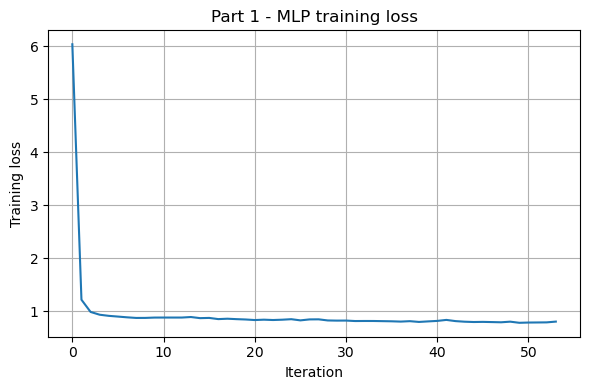

In [55]:
plt.figure(figsize=(6, 4))
plt.plot(mlp_model_clean.named_steps["reg"].loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.title("Part 1 - MLP training loss")
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{fig_dir}/part1_mlp_training_loss.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

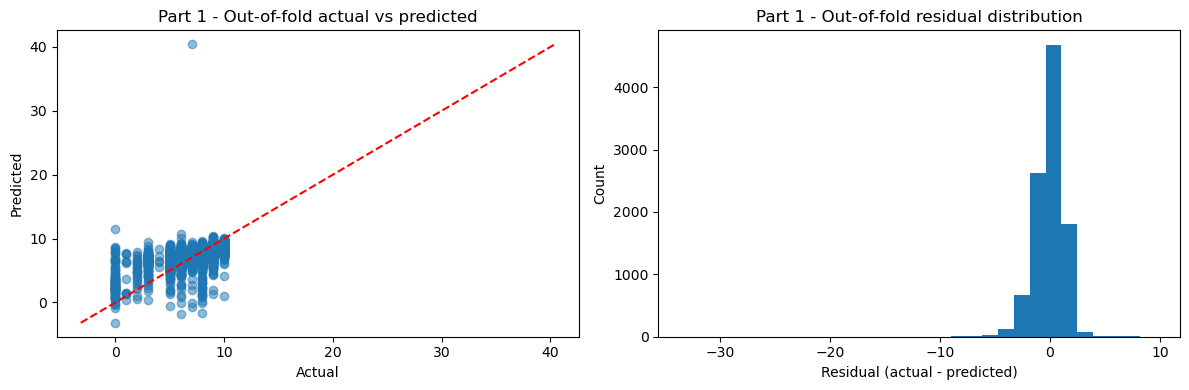

In [56]:
# Out-of-fold diagnostics
residuals = y - y_pred_oof

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(y, y_pred_oof, alpha=0.5)
lims = [min(y.min(), y_pred_oof.min()), max(y.max(), y_pred_oof.max())]
ax[0].plot(lims, lims, "r--")
ax[0].set_title("Part 1 - Out-of-fold actual vs predicted")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")

ax[1].hist(residuals, bins=30)
ax[1].set_title("Part 1 - Out-of-fold residual distribution")
ax[1].set_xlabel("Residual (actual - predicted)")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(f"{fig_dir}/part1_oof_diagnostics.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

In [29]:
# Cell: error analysis — replace X_test/y_test/y_pred with X/y/y_pred_oof
pred_df = X.copy()
pred_df["y_true"] = y.values
pred_df["y_pred"] = y_pred_oof
pred_df["abs_err"] = np.abs(pred_df["y_true"] - pred_df["y_pred"])

print("Top errors by course:")
display(pred_df.groupby("course")["abs_err"].mean().sort_values(ascending=False).head(10))

print("Top errors by text_type:")
display(pred_df.groupby("text_type")["abs_err"].mean().sort_values(ascending=False).head(10))

Top errors by course:


course
5447    1.034559
3301    0.985407
Name: abs_err, dtype: float64

Top errors by text_type:


text_type
bericht         1.046369
beschreibung    1.025552
erzaehlung      1.023348
eroerterung     0.945479
Name: abs_err, dtype: float64

Ridge - 5-fold CV
MAE : 1.0976 +/- 0.0441
RMSE: 1.8448 +/- 0.8446
R2  : -0.6652 +/- 1.6705

Random Forest - 5-fold CV
MAE : 0.9685 +/- 0.0164
RMSE: 1.2977 +/- 0.0299
R2  : 0.3122 +/- 0.0319


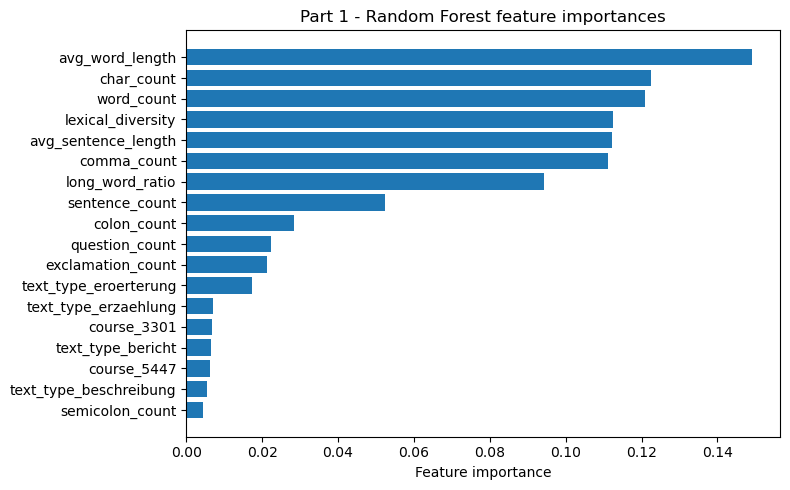

In [57]:
# --- Ridge ---
ridge_p1 = Pipeline([
    ("prep", preprocessor),
    ("reg", Ridge(alpha=1.0))
])

cv_scores_ridge_p1 = cross_validate(
    ridge_p1, X, y, cv=cv_part1,
    scoring={"mae": "neg_mean_absolute_error",
             "rmse": "neg_root_mean_squared_error",
             "r2": "r2"},
    n_jobs=-1
)

print("Ridge - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_ridge_p1["test_mae"].mean(), cv_scores_ridge_p1["test_mae"].std()))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_ridge_p1["test_rmse"].mean(), cv_scores_ridge_p1["test_rmse"].std()))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_ridge_p1["test_r2"].mean(), cv_scores_ridge_p1["test_r2"].std()))

# --- Random Forest ---
rf_p1 = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

cv_scores_rf_p1 = cross_validate(
    rf_p1, X, y, cv=cv_part1,
    scoring={"mae": "neg_mean_absolute_error",
             "rmse": "neg_root_mean_squared_error",
             "r2": "r2"},
    n_jobs=-1
)

print("\nRandom Forest - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_rf_p1["test_mae"].mean(), cv_scores_rf_p1["test_mae"].std()))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_rf_p1["test_rmse"].mean(), cv_scores_rf_p1["test_rmse"].std()))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_rf_p1["test_r2"].mean(), cv_scores_rf_p1["test_r2"].std()))

# --- Feature importance from RF (fit on full data) ---
rf_p1.fit(X, y)
importances = rf_p1.named_steps["reg"].feature_importances_

# Recover feature names after preprocessing
ohe_features = rf_p1.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(cat_cols)
all_feature_names = list(ohe_features) + num_cols

fi_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("Part 1 - Random Forest feature importances")
plt.tight_layout()
plt.savefig(f"{fig_dir}/part1_rf_feature_importances.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## Interim result for Part 1
Using 5-fold cross-validation, simple engineered surface-level linguistic features show a moderate and consistent predictive signal for the essay score `structure__coherence`.

This indicates that observable properties of the text, such as length, sentence structure, lexical diversity, and punctuation patterns, are genuinely informative for essay coherence, but the predictive strength should not be overstated.

This part remains a useful baseline before testing richer semantic representations.

## Part 2 — Essay analysis with richer semantic features
After building a first baseline with simple surface-level linguistic features, we extend the essay analysis by incorporating richer semantic representations of the text.

We ask the following question:

**Do richer semantic text features improve the prediction of essay performance compared with simple linguistic surface features alone?**

In this second step, we keep the same essay-based setting and the same prediction framework, but we move from basic handcrafted features toward more informative text representations.

The goal is to evaluate whether semantic information contained in students' essays provides additional predictive value for essay assessment outcomes.

In [31]:
german_stopwords = [
    "aber", "als", "am", "an", "auch", "auf", "aus", "bei", "bin", "bis",
    "bist", "da", "dadurch", "daher", "darum", "das", "daß", "dass", "dein",
    "deine", "dem", "den", "der", "des", "dessen", "deshalb", "die", "dies",
    "dieser", "dieses", "doch", "dort", "du", "durch", "ein", "eine", "einem",
    "einen", "einer", "eines", "er", "es", "euer", "eure", "für", "hatte",
    "hatten", "hattest", "hattet", "hier", "hinter", "ich", "ihr", "ihre",
    "im", "in", "ist", "ja", "jede", "jedem", "jeden", "jeder", "jedes",
    "jener", "jenes", "jetzt", "kann", "kannst", "können", "könnt", "machen",
    "mein", "meine", "mit", "muß", "mußt", "musst", "müssen", "müsst",
    "nach", "nachdem", "nein", "nicht", "nun", "oder", "seid", "sein",
    "seine", "sich", "sie", "sind", "soll", "sollen", "sollst", "sollt",
    "sonst", "soweit", "sowie", "und", "unser", "unsere", "unter", "vom",
    "von", "vor", "wann", "warum", "was", "weiter", "weitere", "wenn",
    "wer", "werde", "werden", "werdet", "weshalb", "wie", "wieder", "wieso",
    "wir", "wird", "wirst", "wo", "woher", "wohin", "zu", "zum", "zur",
    "über"
]

In [32]:
# data selection for Part 2
df_semantic = essay_results[["course", "text_type", "text", "structure__coherence"]].copy()
df_semantic = df_semantic.dropna(subset=["course", "text_type", "text", "structure__coherence"]).copy()

df_semantic["text_clean"] = df_semantic["text"].apply(helpers_louis.clean_german_essay_text)

X = df_semantic[["course", "text_type", "text_clean"]].copy()
y = df_semantic["structure__coherence"].copy()

cv_part2 = KFold(n_splits=5, shuffle=True, random_state=42)

## Feature Engineering — Part 2 (TF-IDF Semantic Representation)

In Part 2 we move beyond surface structure and represent each essay as a 
high-dimensional vector of weighted word frequencies, using TF-IDF 
(Term Frequency–Inverse Document Frequency). This representation captures 
which words are characteristically used in each essay relative to the full corpus, 
allowing the model to pick up on lexical and topical patterns invisible to surface features.

**Preprocessing pipeline applied to raw German essay text:**
1. Lowercasing and removal of punctuation and digits
2. Tokenization using a custom regex pattern that retains German characters 
   (ä, ö, ü, ß) and filters out tokens shorter than 2 characters
3. Stopword removal using a custom German stopword list (covering function words, 
   pronouns, auxiliary verbs)

**TF-IDF configuration:**
- `ngram_range=(1,1)` — unigrams only, keeping the vocabulary interpretable
- `min_df=3` — terms must appear in at least 3 essays to be included, filtering noise
- `max_df=0.90` — terms appearing in more than 90% of essays are excluded as 
  uninformative
- `max_features=5000` — vocabulary capped at the 5,000 most informative terms
- `sublinear_tf=True` — log-scaling of term frequencies to reduce the dominance 
  of very frequent terms

The same categorical covariates (`course`, `text_type`) from Part 1 are appended 
to the TF-IDF matrix as one-hot encoded columns. The resulting feature matrix 
combines lexical content with contextual metadata, giving the Ridge regression 
model both semantic and structural signals to work with.

The key hypothesis here is that discourse connectors, argumentative vocabulary, 
and topic-relevant terminology should receive high TF-IDF weights in coherent 
essays — and the Ridge coefficients should reflect this if the hypothesis holds.

In [33]:
#Preprocessing
text_col = "text_clean"
cat_cols = ["course", "text_type"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                stop_words=german_stopwords,
                ngram_range=(1, 1),
                min_df=3,
                max_df=0.90,
                max_features=5000,
                sublinear_tf=True,
                token_pattern=r"(?u)\b[a-zA-ZäöüÄÖÜß]{2,}\b"
            ),
            text_col
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        )
    ],
    remainder="drop"
)


In [34]:
# model
ridge_model = Pipeline([
    ("prep", preprocessor),
    ("reg", Ridge(alpha=1.0))
])

In [35]:
# model fitting on full data (for feature inspection)
ridge_model.fit(X, y)

,steps,"[('prep', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


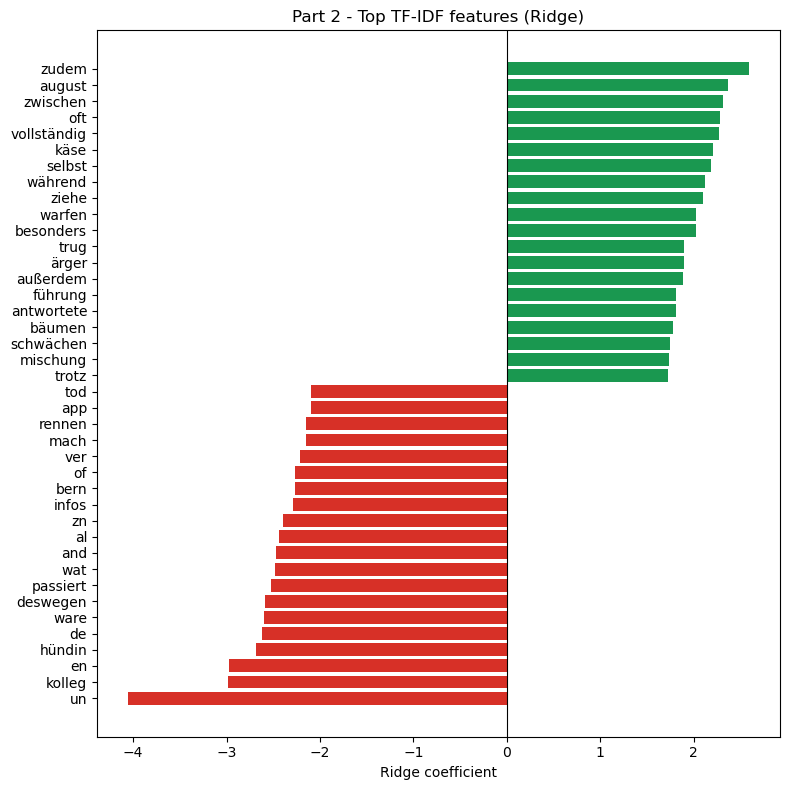

In [58]:
tfidf = ridge_model.named_steps["prep"].named_transformers_["text"]
ridge_coefs = ridge_model.named_steps["reg"].coef_

tfidf_feature_names = tfidf.get_feature_names_out()
ohe_features = ridge_model.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(cat_cols)
all_names = list(tfidf_feature_names) + list(ohe_features)

coef_df = pd.DataFrame({
    "feature": all_names,
    "coef": ridge_coefs
}).sort_values("coef", ascending=False)

# Top 20 positive and negative TF-IDF only (exclude OHE)
coef_tfidf = coef_df[coef_df["feature"].isin(tfidf_feature_names)]
top_pos = coef_tfidf.head(20)
top_neg = coef_tfidf.tail(20)
top = pd.concat([top_pos, top_neg]).sort_values("coef")

plt.figure(figsize=(8, 8))
colors = ["#d73027" if c < 0 else "#1a9850" for c in top["coef"]]
plt.barh(top["feature"], top["coef"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Ridge coefficient")
plt.title("Part 2 - Top TF-IDF features (Ridge)")
plt.tight_layout()
plt.savefig(f"{fig_dir}/part2_top_tfidf_features_ridge.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

Words in red are associated with lower coherence score. Words in green are associated with higher coherence score.

In [39]:
# model evaluation with cross-validation
cv_scores_p2 = cross_validate(
    ridge_model,
    X,
    y,
    cv=cv_part2,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

print("Part 2 - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_p2["test_mae"].mean(), cv_scores_p2["test_mae"].std()
))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_p2["test_rmse"].mean(), cv_scores_p2["test_rmse"].std()
))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_p2["test_r2"].mean(), cv_scores_p2["test_r2"].std()
))

Part 2 - 5-fold CV
MAE : 0.9211 +/- 0.0164
RMSE: 1.2712 +/- 0.0267
R2  : 0.3406 +/- 0.0062


In [40]:
tfidf = ridge_model.named_steps["prep"].named_transformers_["text"]
feature_names = tfidf.get_feature_names_out()

print("nb text features:", len(feature_names))
print(feature_names[:100])

nb text features: 5000
['aarau' 'ab' 'abend' 'abendessen' 'abends' 'abenteuer' 'aberdeen'
 'abfall' 'abgeben' 'abgelegenen' 'abgelenkt' 'abgemacht' 'abgeschafft'
 'abgeschlossen' 'abgesehen' 'abholen' 'abhängig' 'abkürzung'
 'abkürzungen' 'ablenken' 'ablenkung' 'abrupt' 'abschied' 'abschliessend'
 'abschluss' 'abseits' 'absichtlich' 'absolut' 'abstand' 'ach' 'acht'
 'achten' 'achterbahn' 'achterbahnen' 'achtung' 'adern' 'adjektive'
 'adler' 'adrenalin' 'adresse' 'affe' 'affen' 'ah' 'ahmed' 'ahnte'
 'ahnung' 'aisha' 'akku' 'aktion' 'aktiv' 'aktivitäten' 'akzeptieren'
 'akzeptierte' 'al' 'alarm' 'albtraum' 'alexander' 'alexandra' 'algen'
 'alien' 'aliens' 'alkohol' 'all' 'alle' 'allein' 'alleine' 'allem'
 'allen' 'aller' 'allerbesten' 'allerbester' 'allerdings' 'alles'
 'allgemein' 'alls' 'alltag' 'allzu' 'also' 'alt' 'alte' 'alten' 'alter'
 'alternative' 'alters' 'altes' 'ampeln' 'anblick' 'and' 'andere'
 'anderem' 'anderen' 'anderer' 'andererseits' 'anderes' 'andern' 'anders'
 'anderse

## Interim result for Part 2
With 5-fold cross-validation, the German word-level TF-IDF + Ridge model provides a moderate predictive signal for `structure__coherence`.

Compared with the surface-feature baseline, this representation is not dramatically superior, suggesting that essay coherence depends on both structural writing properties and lexical-semantic information.

Overall, cross-validated results support a balanced interpretation: both feature families are relevant, and model selection should rely on validated performance rather than a single split.

## Part 3 — Comparison of surface and word-based text representations

In this part, we compare the two essay-based modeling approaches developed previously:

- Part 1: simple engineered surface-level linguistic features
- Part 2: word-based text representations using TF-IDF

The goal is to assess which type of representation is more informative for predicting the essay score `structure__coherence`, and to better understand what this reveals about the nature of the target.

This comparison helps determine whether essay coherence is better captured by explicit structural features or by lexical content extracted directly from the text.

,MAE,R2
Model,,
Dummy,1.2065 +/- 0.0197,-0.0001 +/- 0.0001
RF (surface),0.9685 +/- 0.0164,0.3122 +/- 0.0319
Ridge (TF-IDF),0.9211 +/- 0.0164,0.3406 +/- 0.0062


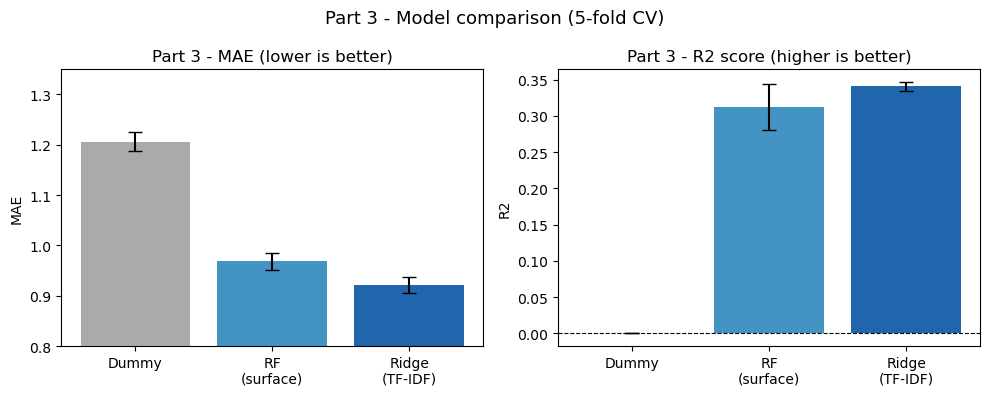

In [59]:
# Part 3
models = ["Dummy", "RF\n(surface)", "Ridge\n(TF-IDF)"]

mae = [-cv_scores_dummy["test_mae"].mean(),
       -cv_scores_rf_p1["test_mae"].mean(),
       -cv_scores_p2["test_mae"].mean()]

mae_std = [cv_scores_dummy["test_mae"].std(),
           cv_scores_rf_p1["test_mae"].std(),
           cv_scores_p2["test_mae"].std()]

r2 = [cv_scores_dummy["test_r2"].mean(),
      cv_scores_rf_p1["test_r2"].mean(),
      cv_scores_p2["test_r2"].mean()]

r2_std = [cv_scores_dummy["test_r2"].std(),
          cv_scores_rf_p1["test_r2"].std(),
          cv_scores_p2["test_r2"].std()]

df_results = pd.DataFrame({
    "Model": models,
    "MAE": [f"{m:.4f} +/- {s:.4f}" for m, s in zip(mae, mae_std)],
    "R2": [f"{r:.4f} +/- {s:.4f}" for r, s in zip(r2, r2_std)],
}).set_index("Model")
display(df_results.style
    .set_caption("Model comparison (5-fold CV)")
    .highlight_min(subset=["MAE"], color="#d4edda")
    .highlight_max(subset=["R2"], color="#d4edda")
)

x = np.arange(len(models))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(x, mae, yerr=mae_std, capsize=5, color=["#aaaaaa", "#4393c3", "#2166ac"])
ax[0].set_xticks(x)
ax[0].set_xticklabels(models)
ax[0].set_ylabel("MAE")
ax[0].set_title("Part 3 - MAE (lower is better)")
ax[0].set_ylim(0.8, 1.35)

ax[1].bar(x, r2, yerr=r2_std, capsize=5, color=["#aaaaaa", "#4393c3", "#2166ac"])
ax[1].set_xticks(x)
ax[1].set_xticklabels(models)
ax[1].set_ylabel("R2")
ax[1].set_title("Part 3 - R2 score (higher is better)")
ax[1].axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.suptitle("Part 3 - Model comparison (5-fold CV)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{fig_dir}/part3_model_comparison_cv.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()